In [ ]:
!gdown http://drive.google.com/uc?id=19526vBYbrKf_5NsH25nLeAN9M_lykzgt
!tar -xf CycleGAN.tar

Downloading...
From (original): http://drive.google.com/uc?id=19526vBYbrKf_5NsH25nLeAN9M_lykzgt
From (redirected): https://drive.google.com/uc?id=19526vBYbrKf_5NsH25nLeAN9M_lykzgt&confirm=t&uuid=3dc6eebf-43de-4788-a80d-f04ccd19b212
To: /content/lab7.tar
100% 2.34G/2.34G [00:30<00:00, 76.8MB/s]


In [2]:
import datetime
print("This code is written at " + str(datetime.datetime.now()))

This code is written at 2025-12-05 03:53:47.798426


## 1. CycleGAN
>
>
> <img src="https://drive.google.com/uc?id=1F12jzfLYThE_Ci-zJ7T761-tq1fGlv3H" alt="no_image" style="width: 800px;"/><br>
>
> * Cycle GAN leverages a cycle consistency in image-to-image translation
> * Unlike a conditional GAN, the cycle GAN considers <U>unpaired training data</U>
>
> **1. Dataset**
>
>   * MNIST dataset
>   * SVHN dataset
>   * Note that the MNIST data is gray, where the number of the channel is 1
>
> **2. Network architecture**
>
>   * **Overall architecture**
>
> <img src="https://drive.google.com/uc?id=1rJyEJOmSeboOsKyFPPoanvkaaiOpXNNA" alt="no_image" style="width: 600px;"/><br>
>
>   * **Generative model G**
>     * Xavier initialization (Glorot & Bengio [3])
>       * It makes sure the weights to keep the propagation in a reasonable range through many layers
>       * $V(W)= {2 \over n_{in}+n_{out}}$
>       * Use <code>nn.init.xavier_uniform_</code> for the Xavier initialization
>
>     * The generative model has three components:
>       1. Encoder:
>         * Convolutional network for feature extracting
>         * 2 convolutional layers and 2 LeakyReLU activations
>         * The output channel sizes are 64, 128 respectively<br>
>         * The kernel size of the convolutional layers are 7 and 3, respectively<br>
>            (You can use different sizes whatever you want, but we recommend those sizes)
>         * All the strides are 2
>         * Use batch normalization except for the first layer
>
>       2. Transformer:
>         * Learn how it would like to transform the feature vector of and image from A to B. <br>
>         * Use the resnet blok which contains the skip-connetction between the input and output for transformation<br>
>            (Please refer to <U>He et al.</U>[3])
>         * 3 resnet block layers and each of layer is followed by LeakyReLU activation
>         * All the output channel sizes are 128
>         * All the kernel sizes and strides are 3 and 1, respectively
>      
>       3. Decoder:
>         * Upconvolutional network for reconstructing an image
>         * 2 upconvolutional layers, one LeakyReLU activations, and one Tanh activation which is for the last layer
>         * The output channel sizes are 128, 64, and 3, respectively for the SVHN data, and 128, 64, and 1, respectively for the MNIST data <br>
>         * All the kernel sizes and strides are 4 and 2, respectively
>         * Use batch normalization except for the last layers
>
>
>
> <img src="https://drive.google.com/uc?id=1bsBowFWGDacoQBUZk-Lzh412IlEUZfmO" alt="no_image" style="width: 800px;"/><br>
>
>
>   * **Discriminative model D**
>     * Xavier Initialization
>     * It contains 4 convolutional layers, 3 LeakyReLU activations, and one Sigmoid activation which is for the last layer
>     * The output channel sizes are 64, 128, 256, and 1, respectively
>     * All the kernel sizes are 4 except for the last kernel size which is 1
>     * The strides from the first two layers are 2 and the rest of them are 1
>     * Use batch normalization([4]) except for the first and last layers
>
>
>
> <img src="https://drive.google.com/uc?id=1BWt04F4K7BSaAANlXvLG_4Jg1Eyk8zsT" alt="no_image" style="width: 600px;"/><br>
>
>
> **3. Loss function**<br>
> (In the paper, the authors use the L2 loss for the GAN loss, but the binary cross entropy loss also works well)
>  * **Discriminative model $D_X$ and $D_Y$**
>    * The loss for $D_Y$ is followed as<br>
>      * Binary cross entropy loss for the real data
>      * Binary cross entropy loss for the fake data <br>
>
>    $-{1 \over N} \sum^{N}_{i=1} l_i^{real}log(D_Y(y_i))+(1-l_i^{real})log(1-D_Y(y_i)) $ <br>
>    $-{1 \over N} \sum^{N}_{i=1} l_i^{fake}log(D_Y(G_Y(x_i)))+(1-l_i^{fake})log(1-D_Y(G_Y(x_i)))$ <br>
>
>  *
>    * The loss for $D_Y$ is followed as<br>
>      * Binary cross entropy loss for the real data
>      * Binary cross entropy loss for the fake data <br>
>
>    $-{1 \over N} \sum^{N}_{i=1} l_i^{real}log(D_X(x_i))+(1-l_i^{real})log(1-D_X(x_i)) $ <br>
>    $-{1 \over N} \sum^{N}_{i=1} l_i^{fake}log(D_X(G_X(y_i)))+(1-l_i^{fake})log(1-D_X(G_X(y_i)))$ <br>
>
>    ($l_i^{real}=1, l_i^{fake}=0$) <br>
>    ($G_Y$ is the generator where $x_i$ translate to $y_i$ and vice versa)
>
>
>  * **Generative model $G_X$ and $G_Y$**<br>
>
>      * Binary cross entropy loss for the real data (It is actually fake)
>
>    $-{1 \over N} \sum^{N}_{i=1} l_i^{real}log(D_X(G_X(y_i)))+(1-l_i^{real})log(1-D_X(G_X(y_i))) $ <br>
>    $-{1 \over N} \sum^{N}_{i=1} l_i^{real}log(D_Y(G_Y(x_i)))+(1-l_i^{real})log(1-D_Y(G_Y(x_i))) $ <br>
>
>    ($l_i^{real}=1$)
>    
>      * The cycle loss for measuring difference between $x_i$ and $G_Y(G_X(x_i))$ and vice versa
>
>    $-{1 \over N} \sum^{N}_{i=1} \lvert\lvert G_Y(G_X(y_i))-y_i \rvert\rvert_1$ <br>
>    $-{1 \over N} \sum^{N}_{i=1} \lvert\lvert G_X(G_Y(x_i))-x_i \rvert\rvert_1$

## 2. Cycle GAN with Pytorch

In [3]:
import os
import os.path as osp
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torch.utils.data
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import time

%matplotlib inline

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"

### Parameter Setting

In [4]:
print('STEP 0: PARAMETER SETTING')

# Data root directory
train_X_root = 'datasets/lab7/mnist/'
train_Y_root = 'datasets/lab7/svhn/'

# Weight save directory
vis_num = 2
save_dir = 'cyclegan'
if not osp.exists(save_dir):
    os.makedirs(save_dir)

# Batch size during training
bs = 64

# Size of image
img_height = 32
img_width = 32
img_size = 32
img_channel = 3

# Channels of generator feature
gfc = 64

# Channels of discriminator feature
dfc = 64

# Number of training epochs
num_epochs = 5

# Learning rate for optimizing
lr = 0.0002

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

# Real or Fake label
real_label = 1
fake_label = 0

STEP 0: PARAMETER SETTING


In [5]:
print('STEP 1: LOADING DATASET')

transform_1ch = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

transform_3ch = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


train_X_set = dset.MNIST(root=train_X_root,
                         train=True,
                         transform=transform_1ch,
                         download=True)
train_Y_set = dset.SVHN(root=train_Y_root,
                        split='train',
                        transform=transform_3ch,
                        download=True)
test_X_set = dset.MNIST(root=train_X_root,
                         train=False,
                         transform=transform_1ch,
                         download=True)
test_Y_set = dset.SVHN(root=train_Y_root,
                        split='test',
                        transform=transform_3ch,
                        download=True)

STEP 1: LOADING DATASET


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 508kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]
100%|██████████| 182M/182M [00:04<00:00, 44.5MB/s]
100%|██████████| 64.3M/64.3M [00:01<00:00, 41.1MB/s]


In [6]:
print('STEP 2: MAKING DATASET ITERABLE')

train_X_loader = torch.utils.data.DataLoader(train_X_set,
                                             batch_size=bs,
                                             shuffle=True,
                                             drop_last=True)

train_Y_loader = torch.utils.data.DataLoader(train_Y_set,
                                             batch_size=bs,
                                             shuffle=True,
                                             drop_last=True)

test_X_loader = torch.utils.data.DataLoader(test_X_set,
                                             batch_size=bs,
                                             shuffle=False,
                                             drop_last=True)

test_Y_loader = torch.utils.data.DataLoader(test_Y_set,
                                             batch_size=bs,
                                             shuffle=False,
                                             drop_last=True)

STEP 2: MAKING DATASET ITERABLE


### Visualize a few images

In [7]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

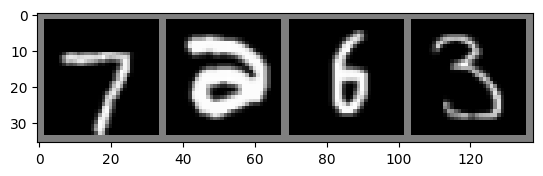

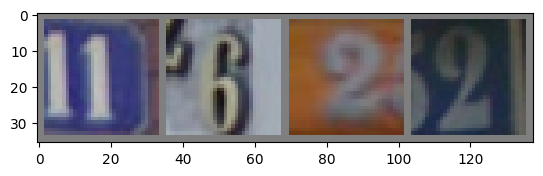

In [8]:
data_loader_X_sample = torch.utils.data.DataLoader(train_X_set,
                                                 batch_size=4,
                                                 shuffle=True)
data_loader_Y_sample = torch.utils.data.DataLoader(train_Y_set,
                                                 batch_size=4,
                                                 shuffle=True)

# Get a batch of training data
X = next(iter(data_loader_X_sample))
Y = next(iter(data_loader_Y_sample))

# Make a grid from batch
out_X = torchvision.utils.make_grid(X[0])
out_Y = torchvision.utils.make_grid(Y[0])

imshow(out_X)
imshow(out_Y)

### Utils
* Use the below code for the convolution or the upconvolution

### *References*
[1] Zhu et al., "Unpaired Image-to-Image Translation using Cycle-Consistent Adversarial Networks", *ICCV*, 2017. <br>
[2] https://hardikbansal.github.io/CycleGANBlog/ <br>
[3] Glorot & Bengio, "Understanding the difficulty of training deep feedforward neural networks", *AISTATS* 2010. <br>
[4] Ioffe & Szegedy, "Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift", *ICML* 2015.

In [9]:
def conv2d(params_list, batch_norm = True):
    channel_in, channel_out, kernel_size, stride, padding, activation = params_list
    layers = []
    if batch_norm:
        layers += [nn.Conv2d(channel_in, channel_out, kernel_size, stride, padding, bias=False),
                   nn.BatchNorm2d(channel_out)]
        nn.init.xavier_uniform_(layers[0].weight)
    else:
        layers += [nn.Conv2d(channel_in, channel_out, kernel_size, stride, padding, bias=False)]
        nn.init.xavier_uniform_(layers[0].weight)

    if activation.lower() == 'relu':
        layers += [nn.ReLU(inplace=True)]
    if activation.lower() == 'leakyrelu':
        layers += [nn.LeakyReLU(0.2, inplace=True)]
    if activation.lower() == 'tanh':
        layers += [nn.Tanh()]
    if activation.lower() == 'sigmoid':
        layers += [nn.Sigmoid()]

    return nn.Sequential(*layers)

def upconv2d(params_list, batch_norm = True):
    channel_in, channel_out, kernel_size, stride, padding, activation = params_list
    layers = []
    if batch_norm:
        layers += [nn.ConvTranspose2d(channel_in, channel_out, kernel_size, stride, padding, bias=False),
                   nn.BatchNorm2d(channel_out)]
        nn.init.xavier_uniform_(layers[0].weight)
    else:
        layers += [nn.ConvTranspose2d(channel_in, channel_out, kernel_size, stride, padding, bias=False)]
        nn.init.xavier_uniform_(layers[0].weight)

    if activation.lower() == 'relu':
        layers += [nn.ReLU(inplace=True)]
    if activation.lower() == 'leakyrelu':
        layers += [nn.LeakyReLU(0.2, inplace=True)]
    if activation.lower() == 'tanh':
        layers += [nn.Tanh()]
    if activation.lower() == 'sigmoid':
        layers += [nn.Sigmoid()]

    return nn.Sequential(*layers)

def transpose(ndarray):
    return np.transpose(ndarray, [0,2,3,1])

def gray2rgb(ndarray):
    return np.concatenate((ndarray, ndarray, ndarray), axis=2)

### 2.1 Generator

In [ ]:
print('STEP 3-1: CREATE MODEL CLASS (Generator)')


# [input channels, output channels, kernel_size, strides, paddings]

# X-domain: MNIST (1ch)   → data_X
# Y-domain: SVHN  (3ch)   → data_Y
# model_G_X(data_X): X(1ch) → Y(3ch)
# model_G_Y(data_Y): Y(3ch) → X(1ch)

cfg_g_enc_X = [
    [1, 64, 7, 2, 3],   # 1ch -> 64ch
    [64, 128, 3, 2, 1], # 64ch -> 128ch
]

cfg_g_enc_Y = [
    [3, 64, 7, 2, 3],   # 3ch -> 64ch
    [64, 128, 3, 2, 1], # 64ch -> 128ch
]

# Transformer (ResNet-like) : 채널 128 유지, stride 1
cfg_g_trans = [
    [128, 128, 3, 1, 1], # Block 1
    [128, 128, 3, 1, 1], # Block 2
    [128, 128, 3, 1, 1], # Block 3
]

# Decoder for G_X : 128 -> 64 -> 3ch (SVHN 스타일)
cfg_g_dec_X = [
    [128, 64, 4, 2, 1], # upconv 1
    [64,   3, 4, 2, 1], # upconv 2 (output 3ch)
]

# Decoder for G_Y : 128 -> 64 -> 1ch (MNIST 스타일)
cfg_g_dec_Y = [
    [128, 64, 4, 2, 1], # upconv 1
    [64,   1, 4, 2, 1], # upconv 2 (output 1ch)
]


class Generator_X(nn.Module):
    """
    G_X: X → Y
    X: MNIST (1ch) → input 1ch
    Y: SVHN  (3ch) → output 3ch
    """
    def __init__(self):
        super(Generator_X, self).__init__()

        # Encoder (X-domain: 1ch 입력)
        # 첫 레이어: BN X, LeakyReLU
        self.enc1 = conv2d(cfg_g_enc_X[0] + ['leakyrelu'], batch_norm=False)
        # 두 번째 레이어: BN O, LeakyReLU
        self.enc2 = conv2d(cfg_g_enc_X[1] + ['leakyrelu'], batch_norm=True)

        # Transformer (ResNet-like 3 block)
        # conv + BN + LeakyReLU 후, forward에서 skip-connection 적용
        self.trans1 = conv2d(cfg_g_trans[0] + ['leakyrelu'], batch_norm=True)
        self.trans2 = conv2d(cfg_g_trans[1] + ['leakyrelu'], batch_norm=True)
        self.trans3 = conv2d(cfg_g_trans[2] + ['leakyrelu'], batch_norm=True)

        # Decoder (Y-domain: 3ch 출력)
        # 첫 upconv: BN O, LeakyReLU
        self.dec1 = upconv2d(cfg_g_dec_X[0] + ['leakyrelu'], batch_norm=True)
        # 마지막 upconv: BN X, Tanh
        self.dec2 = upconv2d(cfg_g_dec_X[1] + ['tanh'], batch_norm=False)

    def forward(self, x):

        # Encoder
        x = self.enc1(x)
        x = self.enc2(x)

        # Transformer with residual connections
        x = x + self.trans1(x)
        x = x + self.trans2(x)
        x = x + self.trans3(x)

        # Decoder
        x = self.dec1(x)
        x = self.dec2(x)

        return x


class Generator_Y(nn.Module):
    """
    G_Y: Y → X
    Y: SVHN  (3ch) → input 3ch
    X: MNIST (1ch) → output 1ch
    """
    def __init__(self):
        super(Generator_Y, self).__init__()

        # Encoder (Y-domain: 3ch 입력)
        self.enc1 = conv2d(cfg_g_enc_Y[0] + ['leakyrelu'], batch_norm=False)
        self.enc2 = conv2d(cfg_g_enc_Y[1] + ['leakyrelu'], batch_norm=True)

        # Transformer (ResNet-like 3 block)
        self.trans1 = conv2d(cfg_g_trans[0] + ['leakyrelu'], batch_norm=True)
        self.trans2 = conv2d(cfg_g_trans[1] + ['leakyrelu'], batch_norm=True)
        self.trans3 = conv2d(cfg_g_trans[2] + ['leakyrelu'], batch_norm=True)

        # Decoder (X-domain: 1ch 출력)
        self.dec1 = upconv2d(cfg_g_dec_Y[0] + ['leakyrelu'], batch_norm=True)
        self.dec2 = upconv2d(cfg_g_dec_Y[1] + ['tanh'], batch_norm=False)


    def forward(self, x):

        # Encoder
        x = self.enc1(x)
        x = self.enc2(x)

        # Transformer with residual connections
        x = x + self.trans1(x)
        x = x + self.trans2(x)
        x = x + self.trans3(x)

        # Decoder
        x = self.dec1(x)
        x = self.dec2(x)

        return x

STEP 3-1: CREATE MODEL CLASS (Generator)


### 2.2 Discriminator

In [ ]:
print('STEP 3-2: CREATE MODEL CLASS (Discriminator)')


# [input channels, output channels, kernel_size, strides, paddings]

# X-domain: MNIST (1ch)
# Y-domain: SVHN  (3ch)
# 4 conv layers, out_channels: 64, 128, 256, 1
# kernel sizes: 4, 4, 4, 1
# strides:      2, 2, 1, 1
# BN: all except first & last  (spec대로)

cfg_d_X = [
    [1,   64, 4, 2, 1],  # (32 -> 16)
    [64, 128, 4, 2, 0],  # (16 -> 7)
    [128,256, 4, 1, 2],  # ( 7 -> 8)
    [256,  1, 1, 1, 0],  # ( 8 -> 8), sigmoid
]

cfg_d_Y = [
    [3,   64, 4, 2, 1],  # (32 -> 16)
    [64, 128, 4, 2, 0],  # (16 -> 7)
    [128,256, 4, 1, 2],  # ( 7 -> 8)
    [256,  1, 1, 1, 0],  # ( 8 -> 8), sigmoid
]


class Discriminator_X(nn.Module):
    def __init__(self):
        super(Discriminator_X, self).__init__()

        self.conv1 = conv2d(cfg_d_X[0] + ['leakyrelu'], batch_norm=False)  # no BN
        self.conv2 = conv2d(cfg_d_X[1] + ['leakyrelu'], batch_norm=True)
        self.conv3 = conv2d(cfg_d_X[2] + ['leakyrelu'], batch_norm=True)
        self.conv4 = conv2d(cfg_d_X[3] + ['sigmoid'],   batch_norm=False)  # last: sigmoid, no BN

    def forward(self, x):

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)   # (B, 1, 8, 8)
        return x


class Discriminator_Y(nn.Module):
    def __init__(self):
        super(Discriminator_Y, self).__init__()

        self.conv1 = conv2d(cfg_d_Y[0] + ['leakyrelu'], batch_norm=False)
        self.conv2 = conv2d(cfg_d_Y[1] + ['leakyrelu'], batch_norm=True)
        self.conv3 = conv2d(cfg_d_Y[2] + ['leakyrelu'], batch_norm=True)
        self.conv4 = conv2d(cfg_d_Y[3] + ['sigmoid'],   batch_norm=False)

    def forward(self, x):

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        return x


STEP 3-2: CREATE MODEL CLASS (Discriminator)


In [25]:
print('STEP 4: INSTANTIATE MODEL CLASS')


model_G_X = Generator_X()
model_G_Y = Generator_Y()
model_D_X = Discriminator_X()
model_D_Y = Discriminator_Y()


#######################
#  USE GPU FOR MODEL  #
#######################


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_G_X.to(device)
print(model_G_X)
model_G_Y.to(device)
print(model_G_Y)
model_D_X.to(device)
print(model_D_X)
model_D_Y.to(device)

STEP 4: INSTANTIATE MODEL CLASS
Generator_X(
  (enc1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (trans1): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (trans2): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (trans3): S

Discriminator_Y(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv4): Sequential(
    (0): Conv2d(256, 1, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): Sigmoid()
  )
)

In [26]:
print('STEP 5: INSTANTIATE LOSS CLASS')

criterion_GAN = nn.BCELoss()
criterion_L1 = nn.L1Loss()

print('STEP 6: INSTANTIATE OPTIMIZER CLASS')

optimizer_G_X = torch.optim.Adam(model_G_X.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_G_Y = torch.optim.Adam(model_G_Y.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D_X = torch.optim.Adam(model_D_X.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D_Y = torch.optim.Adam(model_D_Y.parameters(), lr=lr, betas=(beta1, 0.999))

STEP 5: INSTANTIATE LOSS CLASS
STEP 6: INSTANTIATE OPTIMIZER CLASS


### 2.3 Train the Cycle GAN
* After the training is finished, check out the generated samples
* 1.2GB of GPU memory
* 10~20 mins of training
* Output samples
<img src="https://drive.google.com/uc?id=1PAmQ4XGHH6w24KrFvNOmUER2SAhKp_xN" alt="no_image" style="width: 600px;"/><br>

STEP 7: TRAIN THE MODEL
it[0100/4685] 	Loss_D:1.0738 	Loss_G:1.8844 	Loss_C:0.2238 	elapsed_time:0.12mins
it[0200/4685] 	Loss_D:1.0979 	Loss_G:1.9104 	Loss_C:0.1890 	elapsed_time:0.23mins
it[0300/4685] 	Loss_D:1.0433 	Loss_G:1.9140 	Loss_C:0.1770 	elapsed_time:0.34mins
it[0400/4685] 	Loss_D:1.0198 	Loss_G:2.0995 	Loss_C:0.1678 	elapsed_time:0.45mins
it[0500/4685] 	Loss_D:0.9860 	Loss_G:2.1751 	Loss_C:0.1698 	elapsed_time:0.56mins
it[0600/4685] 	Loss_D:0.9430 	Loss_G:2.3179 	Loss_C:0.1673 	elapsed_time:0.67mins
it[0700/4685] 	Loss_D:0.9661 	Loss_G:2.1892 	Loss_C:0.1668 	elapsed_time:0.79mins
it[0800/4685] 	Loss_D:0.8715 	Loss_G:2.5134 	Loss_C:0.1838 	elapsed_time:0.89mins
it[0900/4685] 	Loss_D:0.9870 	Loss_G:2.4817 	Loss_C:0.1843 	elapsed_time:1.01mins
it[1000/4685] 	Loss_D:0.8446 	Loss_G:2.8056 	Loss_C:0.1907 	elapsed_time:1.12mins


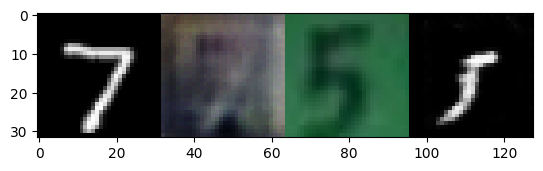

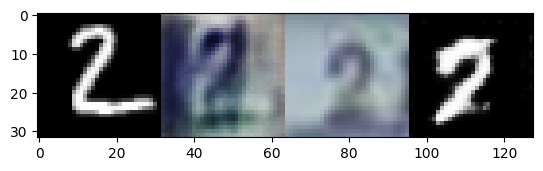

it[1100/4685] 	Loss_D:0.8324 	Loss_G:2.9098 	Loss_C:0.1807 	elapsed_time:1.27mins
it[1200/4685] 	Loss_D:0.9297 	Loss_G:2.6157 	Loss_C:0.1900 	elapsed_time:1.39mins
it[1300/4685] 	Loss_D:0.7388 	Loss_G:2.8544 	Loss_C:0.1844 	elapsed_time:1.49mins
it[1400/4685] 	Loss_D:0.8077 	Loss_G:3.0354 	Loss_C:0.1730 	elapsed_time:1.61mins
it[1500/4685] 	Loss_D:1.1337 	Loss_G:2.8706 	Loss_C:0.1875 	elapsed_time:1.72mins
it[1600/4685] 	Loss_D:0.8953 	Loss_G:3.0915 	Loss_C:0.1795 	elapsed_time:1.83mins
it[1700/4685] 	Loss_D:0.8048 	Loss_G:2.4530 	Loss_C:0.1980 	elapsed_time:1.94mins
it[1800/4685] 	Loss_D:1.0557 	Loss_G:2.4802 	Loss_C:0.1829 	elapsed_time:2.05mins
it[1900/4685] 	Loss_D:0.9381 	Loss_G:2.9547 	Loss_C:0.1897 	elapsed_time:2.16mins
it[2000/4685] 	Loss_D:1.0963 	Loss_G:2.2554 	Loss_C:0.1932 	elapsed_time:2.27mins


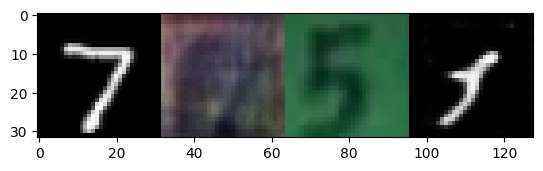

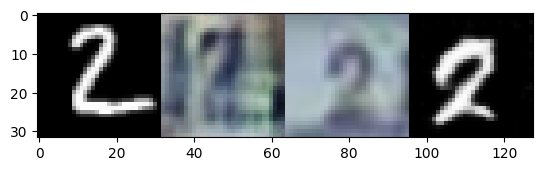

it[2100/4685] 	Loss_D:0.7509 	Loss_G:3.4822 	Loss_C:0.1918 	elapsed_time:2.43mins
it[2200/4685] 	Loss_D:0.8995 	Loss_G:2.8033 	Loss_C:0.2098 	elapsed_time:2.54mins
it[2300/4685] 	Loss_D:0.8279 	Loss_G:3.1984 	Loss_C:0.1927 	elapsed_time:2.65mins
it[2400/4685] 	Loss_D:0.9026 	Loss_G:2.7846 	Loss_C:0.1983 	elapsed_time:2.76mins
it[2500/4685] 	Loss_D:0.8233 	Loss_G:2.9106 	Loss_C:0.1793 	elapsed_time:2.86mins
it[2600/4685] 	Loss_D:0.7830 	Loss_G:3.1897 	Loss_C:0.1888 	elapsed_time:2.98mins
it[2700/4685] 	Loss_D:0.7608 	Loss_G:3.1725 	Loss_C:0.1926 	elapsed_time:3.09mins
it[2800/4685] 	Loss_D:0.7865 	Loss_G:2.9693 	Loss_C:0.1957 	elapsed_time:3.20mins
it[2900/4685] 	Loss_D:0.7347 	Loss_G:2.3623 	Loss_C:0.1947 	elapsed_time:3.31mins
it[3000/4685] 	Loss_D:0.8758 	Loss_G:2.1306 	Loss_C:0.2174 	elapsed_time:3.42mins


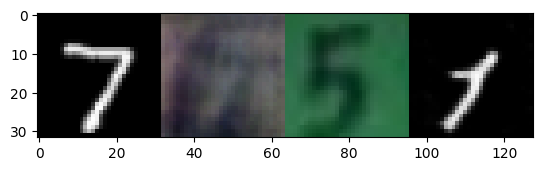

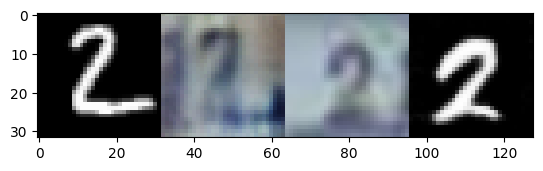

it[3100/4685] 	Loss_D:0.7225 	Loss_G:3.5249 	Loss_C:0.2082 	elapsed_time:3.58mins
it[3200/4685] 	Loss_D:0.9212 	Loss_G:3.4180 	Loss_C:0.2011 	elapsed_time:3.68mins
it[3300/4685] 	Loss_D:0.6778 	Loss_G:3.5171 	Loss_C:0.1963 	elapsed_time:3.80mins
it[3400/4685] 	Loss_D:0.9703 	Loss_G:3.0779 	Loss_C:0.2147 	elapsed_time:3.91mins
it[3500/4685] 	Loss_D:0.9468 	Loss_G:2.1091 	Loss_C:0.1935 	elapsed_time:4.02mins
it[3600/4685] 	Loss_D:0.9395 	Loss_G:2.2055 	Loss_C:0.2077 	elapsed_time:4.13mins
it[3700/4685] 	Loss_D:0.9501 	Loss_G:2.6547 	Loss_C:0.2000 	elapsed_time:4.24mins
it[3800/4685] 	Loss_D:0.8188 	Loss_G:2.9165 	Loss_C:0.2039 	elapsed_time:4.35mins
it[3900/4685] 	Loss_D:0.8239 	Loss_G:3.0629 	Loss_C:0.1934 	elapsed_time:4.46mins
it[4000/4685] 	Loss_D:0.8982 	Loss_G:3.1444 	Loss_C:0.2210 	elapsed_time:4.57mins


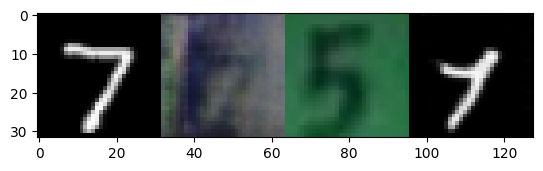

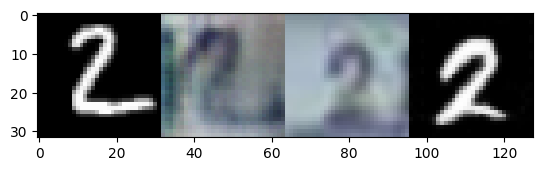

it[4100/4685] 	Loss_D:0.6831 	Loss_G:3.3937 	Loss_C:0.2038 	elapsed_time:4.73mins
it[4200/4685] 	Loss_D:0.7181 	Loss_G:3.3077 	Loss_C:0.2100 	elapsed_time:4.84mins
it[4300/4685] 	Loss_D:0.8504 	Loss_G:3.4289 	Loss_C:0.1896 	elapsed_time:4.95mins
it[4400/4685] 	Loss_D:0.8254 	Loss_G:3.5761 	Loss_C:0.2130 	elapsed_time:5.06mins
it[4500/4685] 	Loss_D:0.7992 	Loss_G:3.4865 	Loss_C:0.2092 	elapsed_time:5.17mins
it[4600/4685] 	Loss_D:0.7286 	Loss_G:3.1072 	Loss_C:0.1996 	elapsed_time:5.28mins


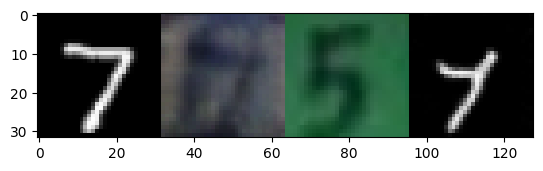

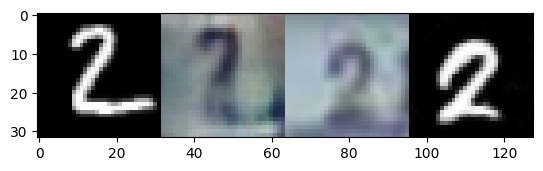

In [ ]:
print('STEP 7: TRAIN THE MODEL')

label_real = torch.full((bs, 1, 8, 8), real_label, dtype=torch.float32, device=device)
label_fake = torch.full((bs, 1, 8, 8), fake_label, dtype=torch.float32, device=device)

num_iter = 0
max_iter = num_epochs*len(train_X_loader)

lambda_cyc = 10.0   # cycle-consistency loss weight

train_start_time = time.time()
for epoch in range(1, num_epochs+1):
    for batch_index, data_X in enumerate(train_X_loader):
        model_G_X.train()
        model_G_Y.train()
        model_D_X.train()
        model_D_Y.train()

        data_X = data_X[0].to(device)                        # X: MNIST
        data_Y = next(iter(train_Y_loader))[0].to(device)    # Y: SVHN

        ### Update discriminator model

        # ---- D_X: real X vs fake X (from G_Y) ----
        optimizer_D_X.zero_grad()

        # real X
        out_real_X = model_D_X(data_X)
        loss_D_X_real = criterion_GAN(out_real_X, label_real)

        # fake X : Y -> G_Y -> X
        fake_X = model_G_Y(data_Y).detach()
        out_fake_X = model_D_X(fake_X)
        loss_D_X_fake = criterion_GAN(out_fake_X, label_fake)

        loss_D_X = 0.5 * (loss_D_X_real + loss_D_X_fake)
        loss_D_X.backward()
        optimizer_D_X.step()

        # ---- D_Y: real Y vs fake Y (from G_X) ----
        optimizer_D_Y.zero_grad()

        # real Y
        out_real_Y = model_D_Y(data_Y)
        loss_D_Y_real = criterion_GAN(out_real_Y, label_real)

        # fake Y : X -> G_X -> Y
        fake_Y = model_G_X(data_X).detach()
        out_fake_Y = model_D_Y(fake_Y)
        loss_D_Y_fake = criterion_GAN(out_fake_Y, label_fake)

        loss_D_Y = 0.5 * (loss_D_Y_real + loss_D_Y_fake)
        loss_D_Y.backward()
        optimizer_D_Y.step()

        err_D = loss_D_X + loss_D_Y


        ### Update generator model

        optimizer_G_X.zero_grad()
        optimizer_G_Y.zero_grad()

        # 다시 forward (detach 없이)
        fake_Y = model_G_X(data_X)   # X -> Y
        fake_X = model_G_Y(data_Y)   # Y -> X

        # adversarial loss for generators
        out_fake_Y = model_D_Y(fake_Y)
        loss_G_X_GAN = criterion_GAN(out_fake_Y, label_real)   # G_X wants D_Y to see fake_Y as real

        out_fake_X = model_D_X(fake_X)
        loss_G_Y_GAN = criterion_GAN(out_fake_X, label_real)   # G_Y wants D_X to see fake_X as real

        # cycle-consistency loss
        rec_X = model_G_Y(fake_Y)   # X -> Y -> X
        rec_Y = model_G_X(fake_X)   # Y -> X -> Y

        loss_cycle_X = criterion_L1(rec_X, data_X)
        loss_cycle_Y = criterion_L1(rec_Y, data_Y)
        loss_cycle = loss_cycle_X + loss_cycle_Y

        # total generator loss
        loss_G = loss_G_X_GAN + loss_G_Y_GAN + lambda_cyc * loss_cycle
        loss_G.backward()
        optimizer_G_X.step()
        optimizer_G_Y.step()

        # logging용 스칼라
        err_G = loss_G_X_GAN + loss_G_Y_GAN   # adversarial part
        err_C = loss_cycle                    # cycle-consistency part

        num_iter += 1
        # Output training stats
        if num_iter%100 == 0:
            print('it[{:04d}/{:04d}] \tLoss_D:{:.4f} \tLoss_G:{:.4f} \tLoss_C:{:.4f} \telapsed_time:{:.2f}mins'.format(
                num_iter, max_iter, err_D.item(), err_G.item(), err_C.item(), (time.time()-train_start_time)/60
            ))

        if num_iter%1000==0 or num_iter==max_iter:
            save_name = osp.join(save_dir, 'it{:04d}.pt'.format(num_iter))
            torch.save({
                'model_G_X': model_G_X.state_dict(),
                'model_G_Y': model_G_Y.state_dict()
            }, save_name)

            with torch.no_grad():
                model_G_X.eval()
                model_G_Y.eval()
                for test_index, data_X in enumerate(test_X_loader):
                    if test_index == 0:

                        data_X = data_X[0].to(device)
                        data_Y = next(iter(test_Y_loader))[0].to(device)

                        output_X = model_G_X(data_X)
                        output_Y = model_G_Y(data_Y)

                        data_X = ((data_X+1)/2).cpu().data.numpy()
                        data_Y = ((data_Y+1)/2).cpu().data.numpy()

                        output_X = ((output_X + 1)/2).cpu().data.numpy()
                        output_Y = ((output_Y + 1)/2).cpu().data.numpy()

                        for vis_idx in range(vis_num):
                            data_X_, data_Y_ = gray2rgb(transpose(data_X)[vis_idx]), transpose(data_Y)[vis_idx]
                            output_X_, output_Y_  = transpose(output_X)[vis_idx], gray2rgb(transpose(output_Y)[vis_idx])
                            outputs = np.concatenate((data_X_, output_X_, data_Y_, output_Y_), axis=1)
                            plt.imshow(outputs)
                            plt.pause(0.001)
